Пример 1

Простейший пример решения задачи оптимизации на PyTorch — минимизация квадратичной функции
f(x)=(x−3)^2.
Цель: найти значение x, при котором функция минимальна (очевидно, x=3).

In [1]:
import torch

# 1. Определяем параметр x (начальное значение, например, 0.0, и говорим, что он требует градиент)
x = torch.tensor([0.0], requires_grad=True)

# 2. Создаём оптимизатор (стохастический градиентный спуск с шагом 0.1)
optimizer = torch.optim.SGD([x], lr=0.1)

# 3. Цикл оптимизации
for step in range(50):
    # Обнуляем градиенты (иначе они накапливаются)
    optimizer.zero_grad()

    # Вычисляем значение функции потерь
    loss = (x - 3) ** 2

    # Вычисляем градиенты loss по x
    loss.backward()

    # Делаем шаг оптимизатора (обновляем x)
    optimizer.step()

    # Выводим информацию каждые 10 шагов
    if step % 10 == 0:
        print(f"Шаг {step:3d}: x = {x.item():.4f}, loss = {loss.item():.6f}")

print(f"\nОптимальное значение x = {x.item():.4f} (должно быть близко к 3)")

Шаг   0: x = 0.6000, loss = 9.000000
Шаг  10: x = 2.7423, loss = 0.103763
Шаг  20: x = 2.9723, loss = 0.001196
Шаг  30: x = 2.9970, loss = 0.000014
Шаг  40: x = 2.9997, loss = 0.000000

Оптимальное значение x = 3.0000 (должно быть близко к 3)


Пример 2. лиенйная регрессия

Epoch  20: loss = 1.0471, w = 2.1088, b = 1.5993
Epoch  40: loss = 0.4212, w = 1.9804, b = 1.4183
Epoch  60: loss = 0.3325, w = 1.9210, b = 1.2997
Epoch  80: loss = 0.2665, w = 1.9731, b = 1.2930
Epoch 100: loss = 0.2511, w = 1.9640, b = 1.2282
Epoch 120: loss = 0.2463, w = 1.9751, b = 1.1901
Epoch 140: loss = 0.2438, w = 1.9803, b = 1.1537
Epoch 160: loss = 0.2424, w = 1.9844, b = 1.1240
Epoch 180: loss = 0.2416, w = 1.9883, b = 1.1014
Epoch 200: loss = 0.2411, w = 1.9909, b = 1.0838

Истинные параметры: w = 2.0, b = 1.0
Найденные параметры: w = 1.9909, b = 1.0838


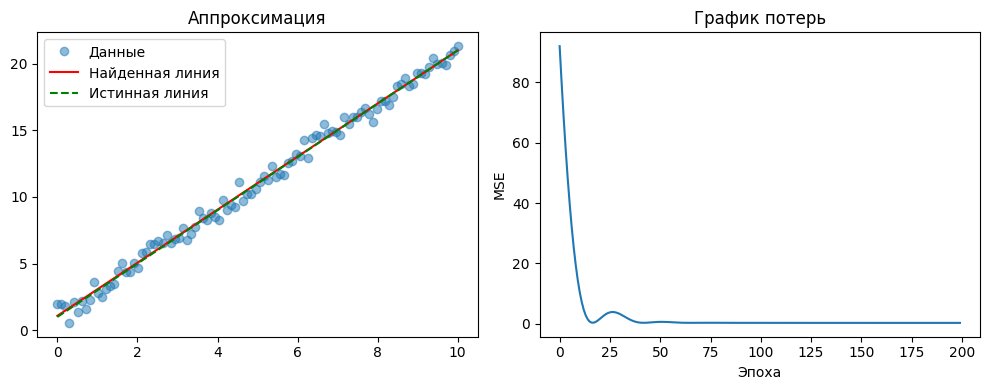

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. Генерируем синтетические данные: y = 2*x + 1 + шум
torch.manual_seed(42)          # для воспроизводимости
x_train = torch.linspace(0, 10, 100).reshape(-1, 1)   # 100 точек от 0 до 10
w_true = 2.0
b_true = 1.0
y_train = w_true * x_train + b_true + torch.randn(x_train.size()) * 0.5  # шум

# 2. Определяем параметры модели (инициализируем случайно)
w = torch.tensor([0.5], requires_grad=True)
b = torch.tensor([0.0], requires_grad=True)

# 3. Оптимизатор (Adam часто работает лучше для таких задач)
optimizer = torch.optim.Adam([w, b], lr=0.1)

# 4. Цикл обучения
losses = []
num_epochs = 200

for epoch in range(num_epochs):
    optimizer.zero_grad()                     # обнуляем градиенты
    y_pred = w * x_train + b                  # предсказание модели
    loss = torch.mean((y_pred - y_train) ** 2) # среднеквадратичная ошибка (MSE)
    loss.backward()                           # вычисляем градиенты
    optimizer.step()                          # обновляем w и b

    losses.append(loss.item())

    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}: loss = {loss.item():.4f}, w = {w.item():.4f}, b = {b.item():.4f}")

print(f"\nИстинные параметры: w = {w_true}, b = {b_true}")
print(f"Найденные параметры: w = {w.item():.4f}, b = {b.item():.4f}")

# 5. Визуализация результатов (если нужен график, раскомментируйте)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(x_train, y_train, 'o', alpha=0.5, label='Данные')
plt.plot(x_train, w.item()*x_train + b.item(), 'r-', label='Найденная линия')
plt.plot(x_train, w_true*x_train + b_true, 'g--', label='Истинная линия')
plt.legend()
plt.title("Аппроксимация")
plt.subplot(1,2,2)
plt.plot(losses)
plt.title("График потерь")
plt.xlabel("Эпоха")
plt.ylabel("MSE")
plt.tight_layout()
plt.show()

Пример 3. Аппроксимация sin

Эпоха  200, Loss = 0.0094
Эпоха  400, Loss = 0.0090
Эпоха  600, Loss = 0.0089
Эпоха  800, Loss = 0.0089
Эпоха 1000, Loss = 0.0089


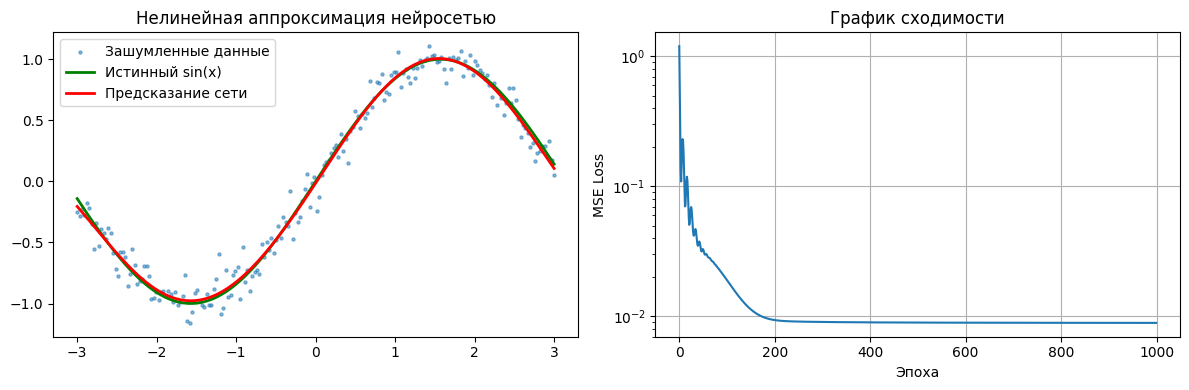

In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# 1. Синтетические данные: y = sin(x) + шум
torch.manual_seed(0)
x_train = torch.linspace(-3, 3, 200).reshape(-1, 1)
y_true = torch.sin(x_train)
y_train = y_true + torch.randn_like(y_true) * 0.1   # добавляем шум

# 2. Определяем простую нейросеть
class SineNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(1, 10)    # вход: 1 признак (x), скрытый слой: 10 нейронов
        self.activation = nn.Tanh()       # нелинейность
        self.output = nn.Linear(10, 1)    # выход: одно предсказание

    def forward(self, x):
        x = self.hidden(x)
        x = self.activation(x)
        x = self.output(x)
        return x

model = SineNet()

# 3. Оптимизатор и функция потерь
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)
criterion = nn.MSELoss()                 # среднеквадратичная ошибка

# 4. Обучение
epochs = 1000
losses = []

for epoch in range(epochs):
    optimizer.zero_grad()
    y_pred = model(x_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    if (epoch+1) % 200 == 0:
        print(f"Эпоха {epoch+1:4d}, Loss = {loss.item():.4f}")

# 5. Визуализация
with torch.no_grad():
    y_pred_final = model(x_train)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.scatter(x_train, y_train, s=5, alpha=0.5, label='Зашумленные данные')
plt.plot(x_train, y_true, 'g-', linewidth=2, label='Истинный sin(x)')
plt.plot(x_train, y_pred_final, 'r-', linewidth=2, label='Предсказание сети')
plt.legend()
plt.title("Нелинейная аппроксимация нейросетью")

plt.subplot(1,2,2)
plt.semilogy(losses)     # логарифмическая шкала для наглядности
plt.xlabel("Эпоха")
plt.ylabel("MSE Loss")
plt.title("График сходимости")
plt.grid(True)
plt.tight_layout()
plt.show()

Пример 4. Оптимизация инвест. портфеля

In [4]:
import torch
import torch.optim as optim

# 1. Исходные данные: ожидаемая доходность 3 активов и ковариационная матрица (риск)
#    Пример: акции, облигации, золото
expected_returns = torch.tensor([0.12, 0.07, 0.05])  # 12%, 7%, 5% годовых

# Ковариационная матрица (вручную для примера)
# [ [акции, акции-облиг, акции-золото],
#   [облиг-акции, облиг, облиг-золото],
#   [золото-акции, золото-облиг, золото] ]
cov_matrix = torch.tensor([
    [0.04, 0.01, 0.02],   # акции (дисперсия 0.04 -> ст.откл 20%)
    [0.01, 0.01, 0.005],  # облигации
    [0.02, 0.005, 0.0225] # золото
], dtype=torch.float)

# 2. Параметры задачи
risk_aversion = 2.0  # коэффициент неприятия риска (чем выше, тем консервативнее)

# 3. Переменные оптимизации: веса портфеля (неотрицательные, сумма = 1)
weights = torch.tensor([0.33, 0.33, 0.34], requires_grad=True)  # начальные веса

# Функция для наложения ограничений: сумма весов = 1, веса >= 0
def project_weights(weights):
    with torch.no_grad():
        # Обрезаем отрицательные значения до 0
        weights.clamp_(min=0)
        # Нормируем так, чтобы сумма стала 1
        weights /= weights.sum()
        weights.data.copy_(weights)  # обновляем

# 4. Оптимизатор (SGD с моментом или Adam)
optimizer = optim.Adam([weights], lr=0.05)

# 5. Цикл оптимизации
epochs = 500
for epoch in range(epochs):
    optimizer.zero_grad()

    # Ограничение: веса должны быть вероятностным распределением
    # Мы применим проекцию после шага, поэтому здесь просто вычисляем loss

    # Ожидаемая доходность портфеля: dot(weights, expected_returns)
    portfolio_return = torch.dot(weights, expected_returns)

    # Риск портфеля: w^T * Cov * w
    portfolio_risk = torch.matmul(weights.T, torch.matmul(cov_matrix, weights))

    # Целевая функция полезности: доходность - aversion * риск
    # (максимизируем её, поэтому в loss ставим минус)
    utility = portfolio_return - risk_aversion * portfolio_risk
    loss = -utility  # минимизируем отрицательную полезность

    loss.backward()
    optimizer.step()

    # Применяем ограничения (сумма весов = 1, неотрицательность)
    project_weights(weights)

    if (epoch+1) % 100 == 0:
        print(f"Эпоха {epoch+1:3d}: Полезность = {utility.item():.4f}, "
              f"Доходность = {portfolio_return.item():.3f}, Риск = {portfolio_risk.item():.4f}")

print("\nОптимальные веса портфеля:")
print(f"Акции:   {weights[0].item():.2%}")
print(f"Облигации:{weights[1].item():.2%}")
print(f"Золото:  {weights[2].item():.2%}")

# Проверка суммы
print(f"Сумма весов = {weights.sum().item():.4f}")

/tmp/ipykernel_1031/2134507358.py:48: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4480.)
  portfolio_risk = torch.matmul(weights.T, torch.matmul(cov_matrix, weights))


Эпоха 100: Полезность = 0.0600, Доходность = 0.095, Риск = 0.0174
Эпоха 200: Полезность = 0.0600, Доходность = 0.095, Риск = 0.0175
Эпоха 300: Полезность = 0.0600, Доходность = 0.095, Риск = 0.0175
Эпоха 400: Полезность = 0.0600, Доходность = 0.095, Риск = 0.0175
Эпоха 500: Полезность = 0.0600, Доходность = 0.095, Риск = 0.0175

Оптимальные веса портфеля:
Акции:   49.89%
Облигации:50.02%
Золото:  0.09%
Сумма весов = 1.0000


Пример 5. Транспортная задача

In [5]:
import torch
import torch.optim as optim

# 1. Данные: 2 склада, 3 магазина
supply = torch.tensor([100.0, 150.0])   # запасы на складах
demand = torch.tensor([80.0, 90.0, 80.0])  # потребности магазинов
cost = torch.tensor([[4.0, 6.0, 8.0],      # стоимость перевозки с 1-го склада
                     [5.0, 7.0, 6.0]])     # со 2-го склада

# 2. Переменная: матрица перевозок X (склады x магазины)
X = torch.tensor([[30.0, 30.0, 40.0],   # начальные приближения (допустимые)
                  [50.0, 60.0, 40.0]], requires_grad=True)

# 3. Функция проекции на допустимое множество (суммы по строкам = supply, по столбцам = demand)
def project(X):
    with torch.no_grad():
        # Нормируем строки на supply
        row_sums = X.sum(dim=1, keepdim=True)
        for i in range(len(supply)):
            if row_sums[i] > 0:
                X[i] = X[i] * (supply[i] / row_sums[i])
        # Нормируем столбцы на demand
        col_sums = X.sum(dim=0, keepdim=True)
        for j in range(len(demand)):
            if col_sums[0, j] > 0:
                X[:, j] = X[:, j] * (demand[j] / col_sums[0, j])
        # Защита от отрицательных (не должно быть, но на всякий случай)
        X.clamp_(min=0)
    return X

# 4. Оптимизатор
optimizer = optim.SGD([X], lr=0.1)

epochs = 500
for epoch in range(epochs):
    optimizer.zero_grad()

    # Общая стоимость перевозок
    total_cost = (X * cost).sum()

    # Штраф за нарушение баланса (в дополнение к проекции, но для стабильности)
    row_balance_penalty = ((X.sum(dim=1) - supply) ** 2).sum()
    col_balance_penalty = ((X.sum(dim=0) - demand) ** 2).sum()

    loss = total_cost + 10.0 * (row_balance_penalty + col_balance_penalty)
    loss.backward()
    optimizer.step()
    with torch.no_grad():
        X.copy_(project(X))

    if (epoch+1) % 100 == 0:
        print(f"Эпоха {epoch+1:3d}: Loss = {loss.item():.2f}, Стоимость = {total_cost.item():.2f}")

print("\nОптимальный план перевозок (матрица X):")
print(X.detach().numpy())
print(f"Суммарная стоимость: {(X * cost).sum().item():.2f}")
print(f"Проверка по складам (должно быть {supply.numpy()}): {X.sum(dim=1).detach().numpy()}")
print(f"Проверка по магазинам (должно быть {demand.numpy()}): {X.sum(dim=0).detach().numpy()}")

Эпоха 100: Loss = 1542.67, Стоимость = 1542.66
Эпоха 200: Loss = 1475.40, Стоимость = 1475.34
Эпоха 300: Loss = 152507.05, Стоимость = 915.16
Эпоха 400: Loss = 1440.33, Стоимость = 1440.13
Эпоха 500: Loss = 1446.55, Стоимость = 1446.40

Оптимальный план перевозок (матрица X):
[[42.82279  45.418285 11.670628]
 [37.177208 44.58172  68.32937 ]]
Суммарная стоимость: 1445.10
Проверка по складам (должно быть [100. 150.]): [ 99.9117  150.08829]
Проверка по магазинам (должно быть [80. 90. 80.]): [80. 90. 80.]
